# Quantum Machine Learning (AIMLZG545)
## Assignment 2: Quantum Approach to a Classical Problem

**Student Name:** Ayushi Gupta  
**Student ID:** 2024AC05720

**Chosen Method:** Variational Quantum Circuit (VQC / VQE)

This notebook builds on Assignment 1 and keeps the same classical problem: **molecular ground-state energy estimation for drug discovery**.

In [1]:
import importlib

import subprocess

import sys



def install_if_missing(packages):

    for package_name in packages:

        try:

            importlib.import_module(package_name)

        except ImportError:

            subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name, '--quiet'])



install_if_missing(['numpy', 'matplotlib', 'scipy', 'qiskit', 'pylatexenc'])

print('Required libraries are available.')

Required libraries are available.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from scipy.optimize import minimize

# Folder where optional generated assets can be saved if needed
OUTPUT_DIR = Path('ass2_notebook_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

# Dataset: bond-distance to 2-qubit Hamiltonian coefficients for H2
EQUILIBRIUM_DISTANCE = 0.735
H2_COEFFICIENTS = {
    0.30: (-0.2253, 0.5678, -0.5678, 0.0908, 0.0908),
    0.40: (-0.5297, 0.5215, -0.5215, 0.0599, 0.0599),
    0.50: (-0.7382, 0.4834, -0.4834, 0.0264, 0.0981),
    0.60: (-0.8816, 0.4497, -0.4497, -0.0021, 0.1282),
    0.70: (-0.9810, 0.4192, -0.4192, -0.0132, 0.1584),
    0.735: (-1.0523732, 0.3979374, -0.3979374, -0.0112801, 0.1809312),
    0.80: (-1.0466, 0.3920, -0.3920, -0.0165, 0.1751),
    0.90: (-1.0858, 0.3677, -0.3677, -0.0165, 0.1867),
    1.00: (-1.1027, 0.3457, -0.3457, -0.0144, 0.1940),
    1.20: (-1.1015, 0.3070, -0.3070, -0.0092, 0.1985),
    1.50: (-1.0597, 0.2590, -0.2590, -0.0030, 0.1900),
    2.00: (-0.9880, 0.2043, -0.2043, 0.0013, 0.1611),
    2.50: (-0.9420, 0.1657, -0.1657, 0.0027, 0.1280),
    3.00: (-0.9170, 0.1380, -0.1380, 0.0030, 0.0997),
}

def make_hamiltonian(coefficients):
    # Convert one row of coefficients into a SparsePauliOp Hamiltonian
    return SparsePauliOp.from_list([
        ('II', coefficients[0]),
        ('IZ', coefficients[1]),
        ('ZI', coefficients[2]),
        ('ZZ', coefficients[3]),
        ('XX', coefficients[4]),
    ])

def build_vqe_circuit(params):
    # 2-qubit hardware-efficient ansatz used by VQE
    qc = QuantumCircuit(2)
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)
    qc.cx(0, 1)
    qc.ry(params[2], 0)
    qc.ry(params[3], 1)
    return qc

def expectation_value(params, hamiltonian):
    # Compute <psi(theta)|H|psi(theta)> for current variational parameters
    state = Statevector.from_instruction(build_vqe_circuit(params))
    return float(np.real(state.expectation_value(hamiltonian)))

def exact_ground_energy(hamiltonian):
    # Exact classical reference via matrix diagonalization
    eigenvalues = np.linalg.eigvalsh(hamiltonian.to_matrix())
    return float(np.min(np.real(eigenvalues)))

def optimize_vqe(hamiltonian, initial_params, maxiter=200):
    # Hybrid loop: classical optimizer calls quantum expectation repeatedly
    history = []

    def objective(params):
        value = expectation_value(params, hamiltonian)
        history.append(value)
        return value

    result = minimize(
        objective,
        initial_params,
        method='COBYLA',
        options={'maxiter': maxiter, 'tol': 1e-6},
    )
    return result, history

np.random.seed(42)
print('Setup complete.')

Setup complete.


## Meaning of `H2_COEFFICIENTS` Data

`H2_COEFFICIENTS` is a lookup table used to build the H2 Hamiltonian at different bond distances.

- **Dictionary key** = bond distance in Angstrom (for example, `0.735`).
- **Dictionary value** = tuple of 5 coefficients:
  1. `c_II` multiplies Pauli term `II`
  2. `c_IZ` multiplies Pauli term `IZ`
  3. `c_ZI` multiplies Pauli term `ZI`
  4. `c_ZZ` multiplies Pauli term `ZZ`
  5. `c_XX` multiplies Pauli term `XX`

For each distance `r`, the Hamiltonian is:

$H(r) = c_{II} II + c_{IZ} IZ + c_{ZI} ZI + c_{ZZ} ZZ + c_{XX} XX$

- Coefficients are in **Hartree** units.
- These are precomputed molecular Hamiltonian coefficients (toy chemistry dataset for H2).
- The key `0.735` corresponds to the equilibrium-distance case used in the main VQE run.

## Required Knowledge to Understand This Notebook

Before reading the implementation, keep these ideas in mind:

1. **Hamiltonian representation**: we model molecular energy with
   $H = c_{II}II + c_{IZ}IZ + c_{ZI}ZI + c_{ZZ}ZZ + c_{XX}XX$.

2. **Ansatz (trial state)**: a parameterized circuit prepares
   $|\psi(\theta)\rangle$ using $R_y$ rotations and a CNOT for entanglement.

3. **Objective function**: VQE minimizes
   $E(\theta) = \langle \psi(\theta) | H | \psi(\theta) \rangle$.

4. **Hybrid loop**:
   - Quantum part: estimate energy for current parameters.
   - Classical part: optimizer (COBYLA) updates parameters.

5. **Validation logic**: compare VQE energy against exact diagonalization and inspect convergence, probabilities, and PES behavior.

## 1. Problem Recap

The classical problem is **molecular ground-state energy estimation**. For a molecule, the ground-state energy is the minimum eigenvalue of its Hamiltonian and determines stability, reactivity, and binding behavior. In drug discovery, accurate molecular energies help estimate whether a candidate molecule binds strongly to a target protein.

This is classically difficult because the wavefunction dimension grows exponentially with system size. Exact simulation methods become infeasible for realistic molecular systems, especially protein-ligand complexes with many interacting electrons.

### Is Energy Minimization a Real Drug-Discovery Problem?

Yes. Energy minimization is a **real and important** subproblem in drug discovery, especially for molecular interactions.

Where it matters most:
- **Binding affinity estimation:** lower interaction energy often indicates stronger protein-ligand binding.
- **Pose refinement:** low-energy binding poses are more physically plausible.
- **Conformer selection:** molecules adopt many shapes; low-energy conformers are typically more relevant.
- **Reaction and stability analysis:** energy landscapes help study reactivity and metabolic behavior.

Drug discovery also includes other major problems:
- activity prediction and virtual screening,
- ADMET/toxicity prediction,
- selectivity and off-target risk,
- synthetic accessibility,
- multi-objective optimization (potency, safety, solubility, stability).

So this notebook addresses a foundational piece of the pipeline (energy-focused molecular modeling), while practical drug design combines this with several additional ML and chemistry tasks.

### Where Ground-State Energy Estimation Fits in the Drug Discovery Pipeline

Ground-state and related energy estimation is a **physics layer** used after initial compound generation/screening and before expensive wet-lab testing.

Typical pipeline placement:
1. **Target identification** (choose protein/biological pathway)
2. **Hit generation** (virtual screening, fragment search, de novo design)
3. **Binding and pose evaluation** (docking + energy-based refinement)  <- this is where energy modeling is central
4. **Lead optimization** (improve potency/selectivity while balancing ADMET)
5. **Preclinical validation** (in vitro/in vivo assays)

What problem this specifically helps solve:
- Rank candidate molecules by physically meaningful interaction quality
- Refine binding poses to remove unrealistic conformations
- Compare stability of molecular conformers and complexes
- Support prioritization before costly synthesis/experiments

So, this notebook focuses on a core subproblem: **accurate quantum-inspired energy estimation**, which strengthens decision quality in the mid-stage molecular evaluation and lead-optimization steps.

## 2. Data Representation

**Input features:** each sample in the dataset is one H2 molecular geometry, described by the bond distance and the five Pauli-term coefficients of the mapped 2-qubit Hamiltonian: $II$, $IZ$, $ZI$, $ZZ$, and $XX$.

**Encoding into quantum states:** the Hamiltonian coefficients are classical descriptors of the molecular instance, while the quantum circuit prepares a trial wavefunction. The circuit uses trainable $R_y$ angles to generate the quantum state.

**Encoding method:** angle encoding, because the trainable quantum state is prepared through rotation angles in the ansatz.

In [3]:
dataset_rows = [
    {
        'bond_distance': distance,
        'c_II': coefficients[0],
        'c_IZ': coefficients[1],
        'c_ZI': coefficients[2],
        'c_ZZ': coefficients[3],
        'c_XX': coefficients[4],
    }
    for distance, coefficients in H2_COEFFICIENTS.items()
]

print(f'Dataset size: {len(dataset_rows)} molecular geometries')
print('Feature names: bond_distance, c_II, c_IZ, c_ZI, c_ZZ, c_XX')
print('First sample:')
print(dataset_rows[0])

Dataset size: 14 molecular geometries
Feature names: bond_distance, c_II, c_IZ, c_ZI, c_ZZ, c_XX
First sample:
{'bond_distance': 0.3, 'c_II': -0.2253, 'c_IZ': 0.5678, 'c_ZI': -0.5678, 'c_ZZ': 0.0908, 'c_XX': 0.0908}


## 3. Quantum Model Design

I use a **Variational Quantum Circuit (VQC)** in VQE form. The ansatz uses four trainable $R_y$ rotation angles and one CNOT gate.

- **Gates used:** $R_y$ and CNOT
- **Entanglement:** introduced by the CNOT gate from qubit 0 to qubit 1
- **Measurement:** expectation value of the molecular Hamiltonian

This design stays within the assignment recommendation of at most 6 qubits because it uses only 2 qubits.

### Why VQC Instead of a Quantum Kernel Method?

I selected **VQC (VQE-style)** because it matches this assignment's molecular-energy objective directly. For this problem, the target is to minimize the Hamiltonian expectation value $E(\theta)=\langle\psi(\theta)|H|\psi(\theta)\rangle$, which is exactly what VQE is designed for.

A quantum kernel approach is usually more natural for supervised tasks (classification/regression) where we learn from labels via similarity matrices. In contrast, this notebook is an **energy minimization** workflow for computational chemistry.

**Can we use QAOA instead?** QAOA is a valid variational quantum algorithm, but it is primarily designed for combinatorial optimization problems (such as MaxCut) with explicit cost and mixer Hamiltonians over bitstrings. Since this assignment targets molecular ground-state energy estimation, VQE provides a more direct chemistry-grounded formulation and easier physical interpretation.

**Drug-discovery example (bigger picture):** imagine ranking two candidate inhibitors for a cancer target protein. If docking scores are close, energy-focused modeling helps decide which candidate has a more physically stable interaction and should be prioritized for synthesis/testing.

Where this fits in the full pipeline:
1. Target identification
2. Candidate generation / virtual screening
3. Binding and pose evaluation (this is where energy-focused modeling is critical)
4. Lead optimization
5. Wet-lab validation

**Decision summary:**
- **Problem fit:** ground-state energy estimation aligns naturally with VQE.
- **Continuity with Assignment 1:** same problem and same scientific pipeline.
- **Rubric alignment:** VQC clearly demonstrates gates, entanglement, measurement, and loss convergence.
- **Qubit efficiency:** the approach works cleanly within the <= 6 qubit recommendation (here, 2 qubits).

Kernel methods and QAOA are both valid in QML, but for this specific chemistry objective , VQC provides the most direct and defensible solution path.

### Method Comparison: VQE vs QNN vs QCNN vs Hybrid QNN

| Method | Best Use Case | Fit for This Assignment | Main Limitation Here |
|---|---|---|---|
| **VQE / VQC** | Ground-state energy estimation from a Hamiltonian | **High (chosen method)** | No practical speed advantage on tiny 2-qubit toy system |
| **QNN** | Supervised classification/regression with labeled data | Medium | Requires reformulating this task into prediction labels instead of direct energy minimization |
| **QCNN** | Structured local data (for example images/spin lattices) with hierarchical feature extraction | Low-Medium | Overkill for small molecular toy setup; less interpretable for this chemistry objective |
| **Hybrid QNN** | Classical feature extractor + quantum layer + classical head | Medium-High (future work) | Needs larger labeled datasets and more tuning; not as direct as VQE for energy minimization |

**Why VQE was selected:** this assignment targets molecular ground-state energy minimization, and VQE directly optimizes $E(\theta)=\langle\psi(\theta)|H|\psi(\theta)\rangle$, making it the most natural and defensible choice here.

VQE circuit architecture:
     ┌─────────┐     ┌─────────┐
q_0: ┤ Ry(0.5) ├──■──┤ Ry(0.5) ├
     ├─────────┤┌─┴─┐├─────────┤
q_1: ┤ Ry(0.5) ├┤ X ├┤ Ry(0.5) ├
     └─────────┘└───┘└─────────┘


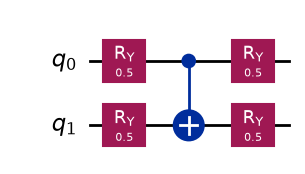

In [4]:
initial_example_params = np.array([0.5, 0.5, 0.5, 0.5])
example_circuit = build_vqe_circuit(initial_example_params)
print('VQE circuit architecture:')
print(example_circuit.draw())
example_circuit.draw('mpl')

## 4. Implementation and Results

The workflow is:
1. Build the molecular Hamiltonian from Pauli coefficients.
2. Compute the exact ground-state energy by classical diagonalization.
3. Optimize a 4-parameter VQE ansatz with COBYLA.
4. Compare exact and VQE energies.
5. Evaluate multiple bond distances to build the potential-energy surface.

### End-to-End Pipeline (with comments)

The next code cell runs a full pipeline in one place:

1. Build the equilibrium Hamiltonian
2. Compute exact energy (classical baseline)
3. Run VQE optimization (hybrid quantum-classical)
4. Build optimized circuit and state
5. Extract basis-state probabilities

This makes the workflow easier to understand and reuse.

In [5]:
def run_equilibrium_vqe_pipeline(seed=42):
    """Run the full equilibrium-point VQE workflow and return all useful artifacts."""
    # Keep runs reproducible for reporting
    np.random.seed(seed)

    # Step 1: Build the Hamiltonian at equilibrium bond distance
    equilibrium_hamiltonian_local = make_hamiltonian(H2_COEFFICIENTS[EQUILIBRIUM_DISTANCE])

    # Step 2: Get exact classical ground-state energy for comparison
    exact_energy_local = exact_ground_energy(equilibrium_hamiltonian_local)

    # Step 3: Initialize trainable angles and run VQE optimizer
    initial_params_local = np.random.uniform(0, 2 * np.pi, size=4)
    optimization_result_local, energy_history_local = optimize_vqe(
        equilibrium_hamiltonian_local, initial_params_local
    )

    # Step 4: Build optimized circuit and final statevector
    optimized_params_local = optimization_result_local.x
    optimized_circuit_local = build_vqe_circuit(optimized_params_local)
    optimized_state_local = Statevector.from_instruction(optimized_circuit_local)

    # Step 5: Convert amplitudes to computational-basis probabilities
    basis_probabilities_local = {
        state: float(probability)
        for state, probability in optimized_state_local.probabilities_dict().items()
    }

    return {
        'equilibrium_hamiltonian': equilibrium_hamiltonian_local,
        'exact_energy': exact_energy_local,
        'initial_params': initial_params_local,
        'optimization_result': optimization_result_local,
        'energy_history': energy_history_local,
        'optimized_params': optimized_params_local,
        'optimized_circuit': optimized_circuit_local,
        'optimized_state': optimized_state_local,
        'basis_probabilities': basis_probabilities_local,
    }

# Run once and expose variables for the rest of the notebook cells
pipeline_results = run_equilibrium_vqe_pipeline(seed=42)
equilibrium_hamiltonian = pipeline_results['equilibrium_hamiltonian']
exact_energy = pipeline_results['exact_energy']
initial_params = pipeline_results['initial_params']
optimization_result = pipeline_results['optimization_result']
energy_history = pipeline_results['energy_history']
optimized_params = pipeline_results['optimized_params']
optimized_circuit = pipeline_results['optimized_circuit']
optimized_state = pipeline_results['optimized_state']
basis_probabilities = pipeline_results['basis_probabilities']

print(f'Exact ground-state energy: {exact_energy:.6f} Hartree')
print(f'VQE ground-state energy:   {optimization_result.fun:.6f} Hartree')
print(f'Absolute error:            {abs(optimization_result.fun - exact_energy):.8f} Hartree')
print(f'Optimizer evaluations:     {optimization_result.nfev}')
print(f'Optimized parameters:      {np.round(optimized_params, 6).tolist()}')

Exact ground-state energy: -1.857275 Hartree
VQE ground-state energy:   -1.857275 Hartree
Absolute error:            0.00000000 Hartree
Optimizer evaluations:     116
Optimized parameters:      [2.900646, 5.904094, 6.1925, 2.752317]


Seed stability test (10 runs):
  num_runs: 10
  exact_energy_mean: -1.8572749403
  vqe_energy_mean: -1.8572749403
  vqe_energy_std: 0.0000000000
  abs_error_mean: 0.0000000000
  abs_error_max: 0.0000000000
  nfev_mean: 124.5000000000
  nfev_max: 148
  success_rate: 1.0000000000


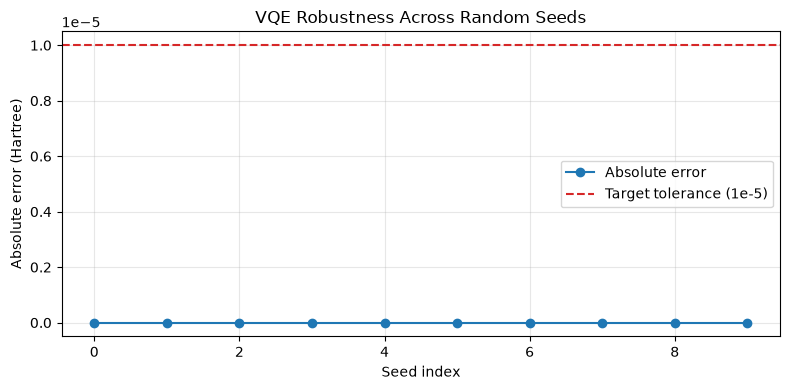

In [6]:
def run_seed_stability_test(num_runs=10, max_allowed_error=1e-5):
    """Run the equilibrium VQE pipeline across random seeds and summarize robustness."""
    all_vqe_energies = []
    all_exact_energies = []
    all_abs_errors = []
    all_nfev = []

    for seed in range(num_runs):
        run_output = run_equilibrium_vqe_pipeline(seed=seed)
        exact_e = run_output['exact_energy']
        vqe_e = float(run_output['optimization_result'].fun)
        abs_err = abs(vqe_e - exact_e)
        nfev = int(run_output['optimization_result'].nfev)

        all_exact_energies.append(exact_e)
        all_vqe_energies.append(vqe_e)
        all_abs_errors.append(abs_err)
        all_nfev.append(nfev)

    success_count = sum(err <= max_allowed_error for err in all_abs_errors)
    success_rate = success_count / num_runs

    summary = {
        'num_runs': num_runs,
        'exact_energy_mean': float(np.mean(all_exact_energies)),
        'vqe_energy_mean': float(np.mean(all_vqe_energies)),
        'vqe_energy_std': float(np.std(all_vqe_energies)),
        'abs_error_mean': float(np.mean(all_abs_errors)),
        'abs_error_max': float(np.max(all_abs_errors)),
        'nfev_mean': float(np.mean(all_nfev)),
        'nfev_max': int(np.max(all_nfev)),
        'success_rate': float(success_rate),
    }

    return summary, all_abs_errors, all_nfev

stability_summary, error_list, nfev_list = run_seed_stability_test(num_runs=10)

print('Seed stability test (10 runs):')
for key, value in stability_summary.items():
    if isinstance(value, float):
        print(f'  {key}: {value:.10f}')
    else:
        print(f'  {key}: {value}')

plt.figure(figsize=(8, 4))
plt.plot(range(len(error_list)), error_list, 'o-', color='#1f77b4', label='Absolute error')
plt.axhline(1e-5, color='#d62728', linestyle='--', label='Target tolerance (1e-5)')
plt.xlabel('Seed index')
plt.ylabel('Absolute error (Hartree)')
plt.title('VQE Robustness Across Random Seeds')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Stronger Validation Pipeline (Does It Really Work?)

To provide stronger evidence than a single run, the next cell repeats the full VQE pipeline with multiple random seeds and summarizes stability.

This helps answer: **"Are results consistent, or just lucky initialization?"**

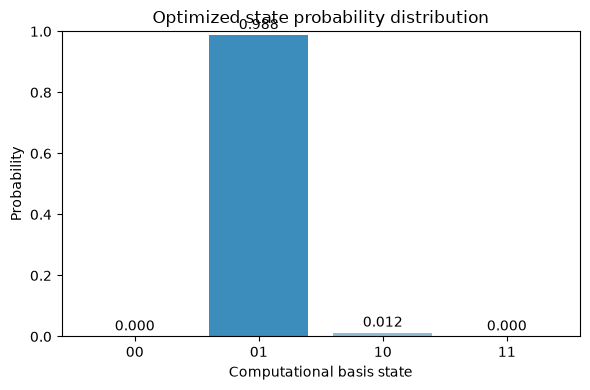

P(00) = 0.000000
P(01) = 0.987560
P(10) = 0.012440
P(11) = 0.000000
This plot shows the measurement probability distribution of the optimized trial state.


In [7]:
states = sorted(['00', '01', '10', '11'])
probabilities = [basis_probabilities.get(state, 0.0) for state in states]

plt.figure(figsize=(6, 4))
plt.bar(states, probabilities, color=['#0f4c81', '#3c8dbc', '#8fbcd4', '#cfe3ef'])
plt.ylim(0, 1)
plt.xlabel('Computational basis state')
plt.ylabel('Probability')
plt.title('Optimized state probability distribution')
for index, value in enumerate(probabilities):
    plt.text(index, value + 0.02, f'{value:.3f}', ha='center')
plt.tight_layout()
plt.show()

for state, value in zip(states, probabilities):
    print(f'P({state}) = {value:.6f}')

print('This plot shows the measurement probability distribution of the optimized trial state.')

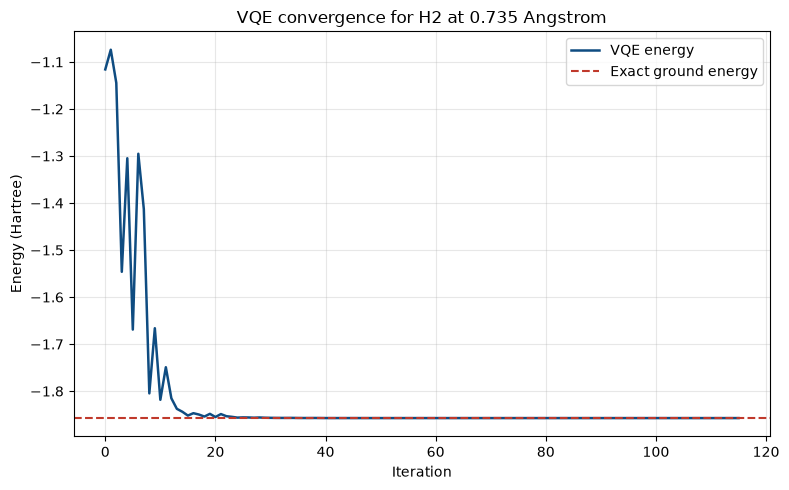

This plot shows loss versus iterations. The VQE estimate converges to the exact ground-state energy.


In [8]:
plt.figure(figsize=(8, 5))
plt.plot(energy_history, color='#0f4c81', linewidth=1.8, label='VQE energy')
plt.axhline(exact_energy, color='#c0392b', linestyle='--', linewidth=1.5, label='Exact ground energy')
plt.xlabel('Iteration')
plt.ylabel('Energy (Hartree)')
plt.title('VQE convergence for H2 at 0.735 Angstrom')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('This plot shows loss versus iterations. The VQE estimate converges to the exact ground-state energy.')

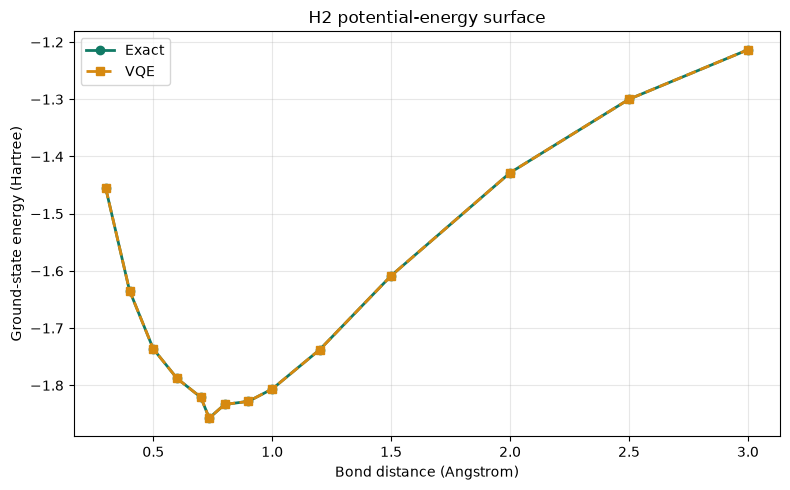

Lowest VQE energy:   -1.857275 Hartree at 0.735 Angstrom
Lowest exact energy: -1.857275 Hartree at 0.735 Angstrom
Max PES absolute error: 0.00000000 Hartree
This plot shows that the VQE model reproduces the potential-energy surface for the toy H2 system.


In [9]:
distances = []
exact_curve = []
vqe_curve = []
warm_start = optimized_params.copy()

for distance, coefficients in H2_COEFFICIENTS.items():
    hamiltonian = make_hamiltonian(coefficients)
    exact_value = exact_ground_energy(hamiltonian)
    result, _ = optimize_vqe(hamiltonian, warm_start, maxiter=150)
    warm_start = result.x

    distances.append(distance)
    exact_curve.append(exact_value)
    vqe_curve.append(float(result.fun))

plt.figure(figsize=(8, 5))
plt.plot(distances, exact_curve, 'o-', color='#117a65', linewidth=2, label='Exact')
plt.plot(distances, vqe_curve, 's--', color='#d68910', linewidth=2, label='VQE')
plt.xlabel('Bond distance (Angstrom)')
plt.ylabel('Ground-state energy (Hartree)')
plt.title('H2 potential-energy surface')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

lowest_vqe_index = int(np.argmin(vqe_curve))
lowest_exact_index = int(np.argmin(exact_curve))
print(f'Lowest VQE energy:   {vqe_curve[lowest_vqe_index]:.6f} Hartree at {distances[lowest_vqe_index]:.3f} Angstrom')
print(f'Lowest exact energy: {exact_curve[lowest_exact_index]:.6f} Hartree at {distances[lowest_exact_index]:.3f} Angstrom')
print(f'Max PES absolute error: {max(abs(a - b) for a, b in zip(exact_curve, vqe_curve)):.8f} Hartree')
print('This plot shows that the VQE model reproduces the potential-energy surface for the toy H2 system.')

### Should We Try a More Real Example?

**Yes, definitely as a next step.** This notebook proves the workflow on a controlled toy system (2-qubit H2). For stronger real-world evidence, move to larger molecular systems using chemistry tooling (for example, `qiskit-nature`) and test noisy simulation or hardware-aware settings.

Suggested progression:
1. H2 (current baseline)
2. LiH or BeH2 with reduced active space
3. Add noise models and compare error growth vs depth
4. Report runtime, optimization stability, and energy accuracy trade-offs

## 5. Discussion and Limitations

**Advantage:** for this 2-qubit toy system, there is no practical speed advantage over classical diagonalization. However, the hybrid VQE workflow is the relevant quantum approach for larger chemistry problems where exact classical methods fail.

**Limitations:** this notebook uses a very small surrogate molecule, precomputed Hamiltonian coefficients, a shallow ansatz, and noiseless simulation. These assumptions make the problem manageable but reduce realism.

**NISQ constraints:** real devices would introduce noise, limited qubit counts, decoherence, and significant measurement overhead. Those constraints would reduce accuracy and make scaling to drug-sized systems difficult on current hardware.

## 6. References

1. Peruzzo, A. et al. *A variational eigenvalue solver on a photonic quantum processor*. Nature Communications, 2014.
2. McArdle, S. et al. *Quantum computational chemistry*. Reviews of Modern Physics, 2020.
3. Cao, Y. et al. *Quantum Chemistry in the Age of Quantum Computing*. Chemical Reviews, 2019.
4. Qiskit documentation for `QuantumCircuit`, `SparsePauliOp`, and statevector simulation.